In [1]:
import numpy as np
import math
from joblib import Parallel, delayed
import matplotlib.pyplot as plt
import time
from itertools import combinations, product
import random

In [2]:
### all ring states
def is_valid_ring(edges, n):
    """Check if a given set of edges forms a valid graph configuration."""
    adjacency = {i: [] for i in range(n)}
    for u, v, _ in edges:
        adjacency[u].append(v)
        adjacency[v].append(u)
   
    # Allow nodes to have 0, 1, or 2 connections
    if any(len(adj) > 2 for adj in adjacency.values()):
        return False
   
    return True  # Allow disconnected nodes or multiple cycles

def generate_ring_states(n, m):
    """Generate all possible unique connectivity states of a graph with n nodes and weighted edges."""
    unique_states = set()

    # Generate all possible edges
    possible_edges = list(combinations(range(n), 2))
   
    # Select up to n edges (allowing fewer edges for cases with 0 or 1 links per node)
    for num_edges in range(len(possible_edges) + 1):  # Consider all possible edge counts
        for edge_set in combinations(possible_edges, num_edges):
            if is_valid_ring([(u, v, 1) for u, v in edge_set], n):
                # Assign weights from 1 to m for each active edge
                for weight_combo in product(range(1, m+1), repeat=len(edge_set)):
                    weighted_edges = [(u, v, w) for (u, v), w in zip(edge_set, weight_combo)]
                    min_representation = tuple(sorted(weighted_edges))
                    unique_states.add(min_representation)

    return [list(state) for state in unique_states]

def edges_to_adjacency_matrix(edges, n):
    """Convert an edge list with weights to an adjacency matrix."""
    matrix = np.zeros((n, n), dtype=int)
    for u, v, w in edges:
        matrix[u][v] = w
        matrix[v][u] = w  # Since it's an undirected graph
    return matrix

def adjacency_matrix_to_edges(matrix):
    """Convert an adjacency matrix to a weighted edge list."""
    edges = []
    n = len(matrix)
    for i in range(n):
        for j in range(i + 1, n):  # Avoid duplicate edges
            if matrix[i][j] > 0:
                edges.append((i, j, matrix[i][j]))
    return edges


n = 3  # Change n to the desired number of nodes
m_star = 2  # Change m to the desired maximum weight
ring_states = generate_ring_states(n, m_star)
all_states=[]
for i, state in enumerate(ring_states):
#     print(f"Ring state {i+1}: {state}")
    adj_matrix = edges_to_adjacency_matrix(state, n)
    all_states.append(adj_matrix)
#     print(f"Adjacency Matrix:\n{adj_matrix}\n")


### all actions

from itertools import product

def is_valid_matrix(diagonal, upper_diagonal, n, corner_value):
    """Check if the matrix satisfies the diagonal restriction rule."""
    diagonal = list(diagonal)  # Convert to a mutable list
    
    # Apply the corner condition if A(0, n-1) is 1
    if corner_value == 1:
        if diagonal[0] == 1 or diagonal[n-1] == 1:
            return False
        diagonal[0] = 0
        diagonal[n-1] = 0

    # Apply the regular diagonal constraints
    for i in range(n - 1):
        if upper_diagonal[i] == 1:  # If (i, i+1) is 1
            if diagonal[i] == 1 or diagonal[i+1] == 1:  # Diagonal must be 0
                return False
            diagonal[i] = 0
            diagonal[i+1] = 0

    return True

def generate_actions(n):
    """Generate all valid symmetric n x n matrices under given constraints."""
    results = []
    
    # Iterate over all possible choices for the diagonal (n elements)
    for diagonal in product([0, 1], repeat=n):
        # Iterate over all possible choices for the upper diagonal (n-1 elements)
        for upper_diagonal in product([0, 1], repeat=n-1):
            # Consider A(0, n-1) being either 0 or 1
            for corner_value in [0, 1]:
                if is_valid_matrix(diagonal, upper_diagonal, n, corner_value):
                    # Construct the full symmetric matrix
                    matrix = [[0] * n for _ in range(n)]
                    
                    for i in range(n):
                        matrix[i][i] = diagonal[i]  # Fill diagonal
                    
                    for i in range(n - 1):
                        matrix[i][i + 1] = matrix[i + 1][i] = upper_diagonal[i]  # Fill upper & lower diagonals

                    # Apply A(0, n-1) if allowed
                    if corner_value == 1:
                        matrix[0][n-1] = matrix[n-1][0] = 1

                    results.append(matrix)
    
    return results


n = 3  # Change this value to generate for different sizes
all_actions = generate_actions(n)


def unique_matrices(matrices):
    """Returns unique matrices from a list by converting to tuples for hashing."""
    unique_set = {tuple(map(tuple, matrix)) for matrix in matrices}
    return [np.array(matrix) for matrix in unique_set]

all_states = unique_matrices(all_states)
all_actions = unique_matrices(all_actions)

# # Print the generated matrices
# for idx, mat in enumerate(all_actions):
#     print(f"Matrix {idx + 1}:\n{mat}\n")

In [3]:
print([len(all_states), len(all_actions)])

[27, 18]


In [4]:
D1_s = []
D2_s = []
for state in all_states:
    D1_s.append(np.linalg.eig(state)[0][0])
    D2_s.append(np.linalg.eig(state)[0][1])  
    
D1_s=np.array(D1_s)
D2_s=np.array(D2_s)

D1_a = []
D2_a = []
for action in all_actions:
    D1_a.append(np.linalg.eig(action)[0][0])
    D2_a.append(np.linalg.eig(action)[0][1])  
    
D1_a=np.array(D1_a)
D2_a=np.array(D2_a)

In [5]:
circuit = [(0,1),(0,2),(1,2)]
all_circ_states = [circuit[i:] for i in range(len(circuit)+1)]


circuit = [(0,1),(0,2)]
all_circ_states = [circuit[i:] for i in range(len(circuit)+1)]
print(all_circ_states)

[[(0, 1), (0, 2)], [(0, 2)], []]


In [6]:
n_state = len(all_states)
n_action = len(all_actions)
n_circ_state = len(all_circ_states)
q_values = np.zeros([n_state,n_circ_state,n_action])

In [7]:
# Train the Model
# Our next task is for our AI agent to learn about its environment by implementing a Q-learning model. 
# The learning process will follow these steps:
# Choose a random, non-terminal state for the agent to begin this new episode.
# Choose an action for the current state. Actions will be chosen using an epsilon greedy algorithm. 
# This algorithm will usually choose the most promising action for the AI agent, 
# but it will occasionally choose a less promising option in order to encourage the agent to explore the environment.
# Perform the chosen action, and transition to the next state (i.e., move to the next location).
# Receive the reward for moving to the new state, and calculate the temporal difference.
# Update the Q-value for the previous state and action pair.
# If the new (current) state is a terminal state, go to #1. Else, go to #2.
# This entire process will be repeated across 1000 episodes. 
# This will provide the AI agent sufficient opportunity to learn the shortest paths 
# Define Helper Functions
def is_allowed_state(state):
    i=0
    res = False
    subset_states = np.nonzero(np.isclose(np.linalg.eig(state)[0][0],D1_s))[0]
    while not res and i<len(subset_states):
        res = np.array_equal(state, all_states[subset_states[i]])
        i+=1 
    return res
#     res = [np.array_equal(state, i) for i in all_states]
#     if  np.argwhere(np.array(res)==True).size==0:
#         return False
#     else:
#         return True

#define a function that determines if the specified location is a terminal state
def is_terminal_state(current_state):
  #if the state has a link between 1st and last node then it is terminal
    if current_state[0][n-1] > 0 and is_allowed_state(current_state):  
        return True
    else:
        return False

def get_state_index(state):
    i=0
    res = False
    subset_states = np.nonzero(np.isclose(np.linalg.eig(state)[0][0],D1_s))[0]
    while not res:
        res = np.array_equal(state, all_states[subset_states[i]])
        i+=1 
    return subset_states[i-1]

# def get_state_index(state):
# #     res = [np.array_equal(state, i) for i in all_states]
# #     index = np.argwhere(np.array(res)==True)[0][0]
#     i=0
#     res = False
#     while not res:
#         res = np.array_equal(state, all_states[i])
#         i+=1 
#     return i-1

def get_action_index(action):
    i=0
    res = False
    subset_actions = np.nonzero(np.isclose(np.linalg.eig(action)[0][0],D1_a))[0]
    while not res:
        res = np.array_equal(action, all_actions[subset_actions[i]])
        i+=1 
    return subset_actions[i-1]

# def get_action_index(action):
#     i=0
#     res = False
#     while not res:
#         res = np.array_equal(action, all_actions[i])
#         i+=1 
#     return i-1

def get_random_state():
    i = np.random.randint(0,len(all_states))
    return all_states[i]

def get_random_action():
    i = np.random.randint(0,len(all_actions))
    return all_actions[i]

#define a function that will choose a random, non-terminal starting state
def get_starting_state():
    
#   get a random state
    current_state = get_random_state()

#   continue choosing random state until a non-terminal state is identified
    while is_terminal_state(current_state):
        current_state = get_random_state()

    return current_state


# define an epsilon greedy algorithm that will choose which action to take next
def get_next_action(current_state, circ_state_index, epsilon):
  #if a randomly chosen value between 0 and 1 is less than epsilon, 
  #then choose the most promising value from the Q-table for this state.
    state_index = get_state_index(current_state)
    
    if np.random.random() < epsilon: #return opt_action 
        action_index = np.argmax(q_values[state_index,circ_state_index])
        opt_action = all_actions[action_index]
        return opt_action
    else: #choose a random action
        return get_random_action()

#define a function that will get the next location based on the chosen action
def get_next_state(current_state, action, p_l, p_bm):
    
    new_state = np.zeros([n,n])
    
    for i in range(n):
        for j in range(n):
            new_state[i][j] = current_state[i][j]
    
    flag=0
    for i in range(n-1):
        if action[i][i+1]>0 or action[0,n-1]>0:
            flag=1
            break
    if np.array_equal(np.zeros([n,n]), action):
            flag=1
            
    if flag==1:
    #     wait                

        for i in range(n-1):
            for j in range(i+1,n):
                if action[i][j] == 0: #wait
                    if new_state[i][j] > 0:
                        new_state[i][j] = (new_state[i][j] + 1)%(m_star+1)
                new_state[j][i] = new_state[i][j]

        if action[0][n-1] == 0: #wait
            if new_state[0][n-1] > 0:
                new_state[0][n-1] = (new_state[0][n-1] + 1)%(m_star+1)

            new_state[n-1][0] = new_state[0][n-1]

    for i in range(n-1):
        j=i+1
        if action[i][j] == 1: #request entanglement
            if np.random.random()<=p_l:
                new_state[i][j] = 1
                new_state[j][i] = 1
            else:
                new_state[i][j] = 0
                new_state[j][i] = 0  

        new_state[j][i] = new_state[i][j]   
        
    if action[0][n-1]==1:
        if np.random.random()<=p_l:
            new_state[0][n-1] = 1
        else:
            new_state[0][n-1] = 0
        new_state[n-1][0] = new_state[0][n-1]
        
    
    
    #Bell measurements
    bell_flag = 0
    for i in range(0,n):
        
        if action[i][i] == 1:  # request BM
            nodes=[]
            node_vals=[]
            for k in np.append(range(0,i+1),range(i+1,n)).astype('int32'):
                
                if new_state[i][k] > 0:
                    nodes.append(k)
                    node_vals.append(new_state[i][k])

            if len(node_vals)==2:
                if np.random.random()<p_bm: #BM success
                    new_state[i][nodes[0]] = 0
                    new_state[i][nodes[1]] = 0
                    new_state[nodes[0]][i] = 0
                    new_state[nodes[1]][i] = 0
                    if node_vals[0] + node_vals[1] - 1 <= m_star:
                        new_state[nodes[0]][nodes[1]] = node_vals[0] + node_vals[1] - 1
                        new_state[nodes[1]][nodes[0]] = node_vals[0] + node_vals[1] - 1
                    else:
                        new_state[nodes[0]][nodes[1]] = 0
                        new_state[nodes[1]][nodes[0]] = 0
                else:                       #BM failure
                    new_state[i][nodes[0]] = 0
                    new_state[nodes[0]][i] = 0
                    new_state[i][nodes[1]] = 0
                    new_state[nodes[1]][i] = 0
                    new_state[nodes[0]][nodes[1]] = 0
                    new_state[nodes[1]][nodes[0]] = 0
            else:
                if len(node_vals)==1:
                    new_state[i][nodes[0]] = 0
                    new_state[nodes[0]][i] = 0
                    
                    
#         for i in range(n):
#             for j in range(i+1,n):
#                 new_state[j][i] = new_state[i][j]
            
    return new_state

In [18]:
def training_network(epsilon, discount_factor, learning_rate, p_l, p_bm, total_episodes, tr):
    
    #run through 'total_episodes' training episodes
    for episode in range(1,int(total_episodes+1)):
        top = random.randint(0,len(all_circ_states)-1)
        if episode%10000==0:
            print(episode)
            if epsilon<0.8 and episode>int(total_episodes/2):
                epsilon+=0.05
            if learning_rate>0.001:
                learning_rate = learning_rate/1.25
        
        #get the starting state for this episode
        state = get_starting_state()
        circ_state = all_circ_states[top]
        
        
        #continue taking actions until we reach a terminal state or we do 1000 actions
        trial_num = 0
#         t0= time.time()
        while trial_num<=1000 and len(circ_state)>0:
            
            #choose which action to take
            
            action = get_next_action(state, top, epsilon)
            
            #perform the chosen action, and transition to the next state
            old_state = np.zeros([n,n]) #store the old state
            for i in range(n):
                for j in range(n):
                    old_state[i][j] = state[i][j]
            
            old_circ_state_index = top
             
            state = get_next_state(old_state, action, p_l, p_bm)
            
            for nodes in circ_state:
                if state[nodes[0],nodes[1]]>0 and state[nodes[0],nodes[1]]<=m_star:
                    top+=1
                    state[nodes[0],nodes[1]] = 0
                    state[nodes[1],nodes[0]] = 0
                    circ_state = all_circ_states[top]
                else:
                    break
                    
            if not is_allowed_state(state):
                state = np.zeros([n,n])
                print('hello')
                 
    
            state_index = get_state_index(state)
            circ_state_index = top
            old_state_index = get_state_index(old_state)
            action_index = get_action_index(action)

            
            #receive the reward for moving to the new state, and calculate the temporal difference
            
            if len(circ_state)>0:
                reward = -1  #stack is not empty
            else:
                reward = 100 #stack is empty
            
            
            old_q_value = q_values[old_state_index,old_circ_state_index][action_index]
            temporal_difference = reward + (discount_factor * np.max(q_values[state_index,circ_state_index])) - old_q_value

            #update the Q-value for the previous state and action pair
            new_q_value = old_q_value + (learning_rate * temporal_difference)
            q_values[old_state_index,old_circ_state_index][action_index] = new_q_value
            trial_num = trial_num + 1
            
#             if top==3:
#                 print('success')
#             if trial_num==1000:
#                 print('fail')
                
        if episode%10000==0:
            np.save("q_values_3ring_plpt25_ps1_m2_shorttrial_"+str(int(tr))+"new.npy",q_values)
#         print(time.time()-t0)     
    print('Training complete!')

In [19]:
total_episodes = 20000
learning_rate = 0.1
p_l = 0.25
p_bm = 1
epsilon = 0.2
discount_factor = 0.8
seeds = [41, 53, 10, 9, 99, 86, 44, 38, 71, 25]
for tr in range(10):
    SEED = seeds[tr]
    random.seed(SEED)
    np.random.seed(SEED)
    print(tr)
    q_values = np.zeros([n_state,n_circ_state,n_action])
#     q_values = np.load("q_values_3ring_plpt25_ps1_m5_trial_"+str(int(tr))+"_eps_"+str(epsilon)+"df"+str(discount_factor)+".npy", allow_pickle=True)
    t0=time.time()
    training_network(epsilon, discount_factor, learning_rate, p_l, p_bm, total_episodes,tr)
    print(time.time()-t0)
    
# Parallel(n_jobs=15)(delayed(training_network)(epsilon, discount_factor, learning_rate, p_l, p_bm, total_episodes,tr) for tr in range(10))
#q_values = np.load("q_values_3ring_"+str(50000)+"_m10_short.npy", allow_pickle=True)

# t0=time.time()
# training_network(epsilon, discount_factor, learning_rate, p_l, p_bm, total_episodes,rd)
# print(time.time()-t0)

0
10000
20000
Training complete!
75.81386828422546
1
10000
20000
Training complete!
74.4975049495697
2
10000
20000
Training complete!
74.36683750152588
3
10000
20000
Training complete!
75.8379168510437
4
10000
20000
Training complete!
74.18302750587463
5
10000
20000
Training complete!
74.69136929512024
6
10000
20000
Training complete!
73.68536734580994
7
10000
20000
Training complete!
75.53389477729797
8
10000
20000
Training complete!
73.22411012649536
9
10000
20000
Training complete!
74.1684775352478


In [9]:
circuit = [(0,1),(0,2)]
all_circ_states = [circuit[i:] for i in range(len(circuit)+1)]
print(all_circ_states)

[[(0, 1), (0, 2)], [(0, 2)], []]


In [10]:
def shortest_path(start_state, p_l, p_bm):
    
    current_state = np.array([i for i in start_state])
    evolution_path = []
    evolution_path.append(current_state)
    nr=0
    trial_num=0
    top = 0
    circ_state = all_circ_states[top]
    #continue moving along the path until we reach the goal (i.e., all active node state)
    while len(circ_state)>0:
        #get the best action to take
        action = get_next_action(current_state, top, 1.)
#         print(current_state)
#         print(action)
        flag=0
        for i in range(n-1):
            if action[i][i+1]>0:
                flag=1
                break
        if np.array_equal(np.zeros([n,n]), action):
            flag=1
        #move to the next location on the path, and add the new location to the list
        current_state = np.array([i for i in get_next_state(current_state, action, p_l, p_bm)])
        
        for nodes in all_circ_states[top]:
            if current_state[nodes[0],nodes[1]]>0 and current_state[nodes[0],nodes[1]]<=m_star:
                top+=1
                current_state[nodes[0],nodes[1]] = 0
                current_state[nodes[1],nodes[0]] = 0
                circ_state = all_circ_states[top]
            else:
                break
        
        if flag==1:
            evolution_path.append(current_state)
        
        trial_num+=1
        
    evolution_path.append(current_state)    
    
    return evolution_path

In [206]:
q_values = np.load("q_values_3ring_plpt25_ps1_m2_longtrial_"+str(int(1))+".npy", allow_pickle=True)
get_next_action(np.array([[0,1,0],
                         [1,0,1],
                         [0,1,0]]),0,1.) 

array([[0, 0, 1],
       [0, 0, 1],
       [1, 1, 0]])

In [94]:
get_next_state(np.array([[0,1,0],
                         [1,0,1],
                         [0,1,0]]), np.array([[0, 0, 0],
       [0, 1, 0],
       [0, 0, 0]]), 1, 1)

array([[0., 0., 1.],
       [0., 0., 0.],
       [1., 0., 0.]])

In [70]:
p_bm = 1
# wt_RL2=[]; 
wt_RL = []; 
wt_sq=[]; wt_pl=[]; wt_sa=[]
for p_l in np.linspace(0.05,0.5,10):
    if p_l<=0.25:
        q_values = np.load("q_values_3ring_plpt25_ps1"+str(100000)+"_m15_short.npy", allow_pickle=True)
#         q_values = np.load("q_values_3ring_plpt25_ps1"+str(100000)+"_m15_R100.npy", allow_pickle=True)
    else:
        q_values = np.load("q_values_3ring_plpt25_ps1"+str(100000)+"_m15_short.npy", allow_pickle=True)
#         q_values = np.load("q_values_3ring_plpt25_ps1"+str(100000)+"_m15_R100.npy", allow_pickle=True)
    
    wt=[]
    wt2=[]
    for i in range(5000):
        wt.append(len(shortest_path(np.zeros([n,n]),p_l, p_bm)))
#         wt2.append(len(shortest_path(np.zeros([n,n]),p_l, p_bm)))
        

    print(np.mean(wt))
#     print(np.mean(wt2))
    wt_RL.append(np.mean(wt))
#     wt_RL2.append(np.mean(wt2))
    
    wt_pl.append((3-p_l**2)/(p_l*(2-p_l)))
    wt_sa.append((((1/2*p_l) + (3-p_l**2)/(p_l*p_bm*(2-p_l)))**(-1) + p_l*(2-p_l)/(3-p_l**2))**(-1))
    wt_sq.append(2/p_l)
    

20.0724
10.3198
7.5538
6.2476
5.5622
5.0326
4.6214
4.3772
4.1782
4.0226


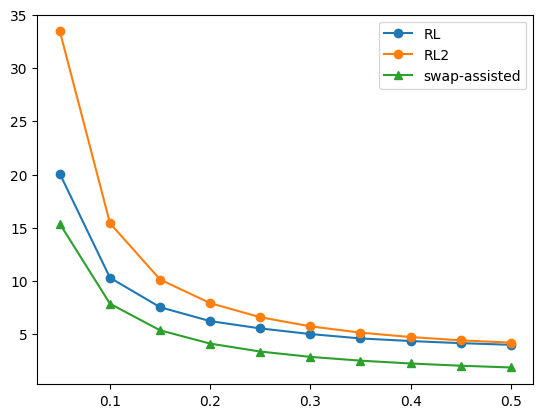

In [71]:
import matplotlib.pyplot
# plt.plot(np.linspace(0.05,0.5,10),wt_pl,marker='d')
plt.plot(np.linspace(0.05,0.5,10),wt_RL,marker='o')
plt.plot(np.linspace(0.05,0.5,10),wt_RL2,marker='o')
# plt.plot(np.linspace(0.05,0.5,10),wt_sq,marker='*')
plt.plot(np.linspace(0.05,0.5,10),wt_sa,marker='^')
plt.legend(['RL','RL2','swap-assisted'])

In [11]:
p_bm = 1
p_l = 0.25
wt_RL = []
wt_std = []
rd = 100.
discount_factor = 0.8
epsilon = 0.25
for tr in range(10):
    q_values = np.load("q_values_3ring_plpt25_ps1_m2_longtrial_"+str(int(tr))+"new.npy", allow_pickle=True) 
    wt_list = []
    for k in range(10):
        wt = []
        for i in range(1000):
            wt.append(len(shortest_path(np.zeros([n,n]),p_l, p_bm)))
        wt_list.append(np.mean(wt))

        print(np.mean(wt))
    wt_RL.append(np.mean(wt_list))
    wt_std.append(np.std(wt_list))

7.694
7.616
7.625
7.579
7.717
7.646
7.588
7.506
7.416
7.357
7.962
7.884
7.871
7.997
8.051
8.03
8.118
8.222
7.992
7.964
7.791
7.606
7.619
7.732
7.467
7.616
7.618
7.641
7.583
7.573
7.799
7.592
7.89
7.959
8.066
7.921
7.893
7.837
8.201
7.687
8.231
7.915
7.941
8.078
7.85
7.703
8.106
8.123
7.928
8.015
8.011
8.137
8.123
7.914
7.952
8.132
8.131
7.979
8.023
8.089
7.593
7.789
7.905
7.751
7.887
7.629
7.775
7.875
7.619
7.738
8.119
8.354
8.311
8.106
8.432
8.165
8.248
8.039
8.429
8.335
7.704
7.699
7.892
7.832
7.482
7.692
7.707
7.924
7.762
7.827
7.812
7.962
7.822
7.752
8.113
8.045
7.937
8.018
7.8
7.997


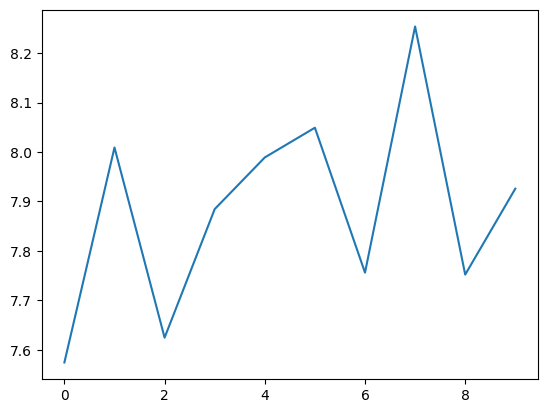

In [12]:
plt.plot(wt_RL)

In [20]:
p_bm = 1
wt_RL = []; 
wt_sq=[]; wt_pl=[]; wt_sa=[]
m = 2

for p_l in [0.25]:#np.linspace(0.05,0.5,10):
    q_values = np.load("q_values_3ring_plpt25_ps1_m2_longtrial_"+str(int(0))+"new.npy", allow_pickle=True)
    wt=[]
    for i in range(500):
        wt.append(len(shortest_path(np.zeros([n,n]),p_l, p_bm)))
    print(np.mean(wt))
    wt_RL.append(np.mean(wt))
    
    q_l = 1-p_l
    # infinite memory doubling time
    T_sw_inf = (3-p_l**2)/(p_l*p_bm*(2-p_l))

    #finite memory doubling time
    T_sw = (T_sw_inf - ((1+p_l)*q_l**(m+1))/(p_l*p_bm*(1-p_l/2)))/(1 - q_l**(m+1)/(1-p_l/2)) 

    # non-swap-assisted paths
    T1 = 2/p_l
    T2 = 1/p_l + 1/(p_l*q_l**(m-1))
    
    #swap assisted paths
    T3 = 1/p_l + T_sw #link (0,1) is created first
    
    # probability of doubling success with finite memory
    p_sd = 1/T_sw
    
    T4 = 1/p_l + 1/(p_sd*(1-p_sd)**(m-1)) #link (0,2) is created first so the other must succeed in m steps.

    T_sa = (1/T1 + 1/T2 + 1/T3 + 1/T4)**(-1)
    T_pl = (1/T1 + 1/T2)**(-1)
    
    wt_pl.append(T_pl)
    wt_sa.append(T_sa)
    wt_sq.append(2/p_l)

7.796


In [22]:
T_pl

4.3076923076923075

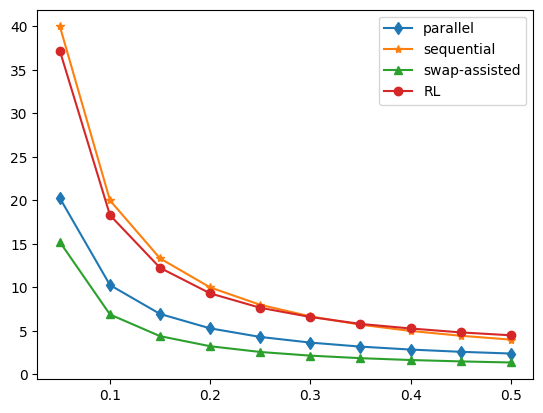

In [16]:
import matplotlib.pyplot
plt.plot(np.linspace(0.05,0.5,10),wt_pl,marker='d')
plt.plot(np.linspace(0.05,0.5,10),wt_sq,marker='*')
plt.plot(np.linspace(0.05,0.5,10),wt_sa,marker='^')
plt.plot(np.linspace(0.05,0.5,10),wt_RL,marker='o')
plt.legend(['parallel','sequential','swap-assisted','RL'])